# PROYECTO FINAL

## 1. Librerías y clases de prácticas

In [1]:
#Importamos las librerías básicas para trabajar con datos, cálculos numéricos y gráficos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Cargamos las clases y métricas que hemos creado en las prácticas de la asignatura + alguna modificación que hemos hecho para poder usarlas en el proyecto
from src.knn import knn
from src.knn_regression import KNNRegresion
from src.metrics import (
    accuracy_score_manual,
    confusion_matrix_multiclase,
    f1_macro_manual,
    mae_manual,
    rmse_manual,
    r2_manual)
from src.logistic_regression import LogisticRegressorMulticlase
from src.regression import LinearRegressor, evaluate_regression


## 2. Carga y limpieza inicial de los datos

Lo primero es cargar el dataset y tratar el valor "en_blanco" como un verdadero nulo. Si no lo hacemos, el modelo interpretaría esa cadena como si fuera una categoría válida y eso introduciría ruido.

Después eliminamos únicamente las filas con ausencia en ocupacion_madre y ocupacion_padre porque son muy pocas, ya que como vimos en clase cuando el número de ausencias es pequeño, puede ser más razonable eliminar esas observaciones que inventar información mediante imputación.

In [2]:
#Cargamos el dataset y convertimos el valor en_blanco en un nulo real para poder limpiarlo correctamente.
df = pd.read_csv("data/rendimiento_estudiantes.csv", sep=";")
df = df.replace("en_blanco", np.nan)

#Aquí lo que estamos haciendo es eliminar solo las filas con ocupación de madre o padre vacía, porque son pocos casos y evitan problemas posteriores.
df = df.dropna(subset=["ocupacion_madre", "ocupacion_padre"]).copy()

#Comprobamos el tamaño final del dataset y vemos las primeras filas.
print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (4403, 37)


,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


## 3. Comprobaciones rápidas del dataset

Antes de modelar, conviene revisar nulos, duplicados e incoherencias básicas en las variables académicas, ya que un mal preprocesamiento arrastra errores a todo el análisis. Por eso primero hay que comprobar que los datos tienen sentido.

En concreto nos interesa ver:

- si aún quedan nulos
- si hay filas duplicadas
- si existen inconsistencias lógicas, por ejemplo más asignaturas evaluadas que matriculadas
- cómo está distribuida la variable objetivo, porque el desbalance de clases afecta directamente a la evaluación en clasificación

In [3]:
#Revisamos si quedan columnas con valores nulos después de la limpieza inicial.
nulos = df.isnull().sum()
print("Columnas con nulos:")
print(nulos[nulos > 0])
print()

#Comprobamos si hay filas duplicadas en el dataset.
print("Filas duplicadas:", df.duplicated().sum())
print()

#Aquí lo que estamos haciendo es buscar incoherencias académicas, por ejemplo tener más asignaturas evaluadas que matriculadas.
print("1er semestre: evaluadas > matriculadas:",(df["asignaturas_1sem_evaluadas"] > df["asignaturas_1sem_matriculadas"]).sum(),)
print("2do semestre: evaluadas > matriculadas:",(df["asignaturas_2sem_evaluadas"] > df["asignaturas_2sem_matriculadas"]).sum())

#Por otro lado, aquí lo que estamos revisando casos raros donde la nota media sea 0 aunque el alumno sí tenga asignaturas evaluadas.
print("nota_media_1sem = 0 con asignaturas evaluadas > 0:",((df["nota_media_1sem"] == 0) & (df["asignaturas_1sem_evaluadas"] > 0)).sum())
print("nota_media_2sem = 0 con asignaturas evaluadas > 0:",((df["nota_media_2sem"] == 0) & (df["asignaturas_2sem_evaluadas"] > 0)).sum())


Columnas con nulos:
Series([], dtype: int64)

Filas duplicadas: 0

1er semestre: evaluadas > matriculadas: 2784
2do semestre: evaluadas > matriculadas: 2652
nota_media_1sem = 0 con asignaturas evaluadas > 0: 363
nota_media_2sem = 0 con asignaturas evaluadas > 0: 461


objetivo
graduado       2205
abandono       1406
matriculado     792
Name: count, dtype: int64

objetivo
graduado       50.08
abandono       31.93
matriculado    17.99
Name: count, dtype: float64


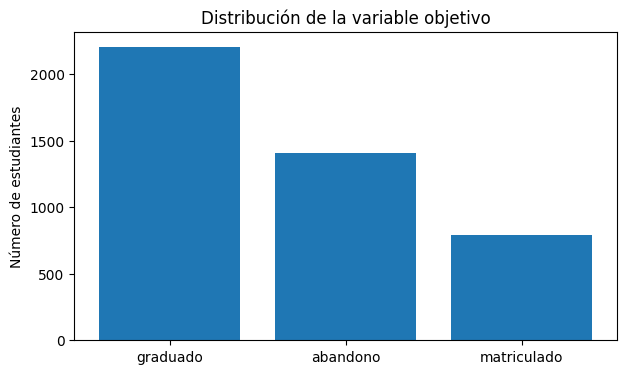

In [4]:
#Calculamos cuántos alumnos hay en cada clase objetivo y su porcentaje sobre el total.
conteo_objetivo = df["objetivo"].value_counts()
porcentaje_objetivo = (100 * conteo_objetivo / len(df)).round(2)

#Y luego mostramos la distribución de la variable objetivo para detectar si las clases están equilibradas o no.
print(conteo_objetivo)
print()
print(porcentaje_objetivo)

#También representamos gráficamente esa distribución para verla de forma más clara.
plt.figure(figsize=(7, 4))
plt.bar(conteo_objetivo.index, conteo_objetivo.values)
plt.title("Distribución de la variable objetivo")
plt.ylabel("Número de estudiantes")
plt.show()


La distribución de objetivo no es uniforme, así que no conviene quedarnos solo con accuracy como medida para valorar si funciona bien o no.

En clase vimos que cuando las clases están desbalanceadas una exactitud alta puede ser engañosa, porque un modelo puede acertar mucho simplemente favoreciendo a la clase mayoritaria. Por eso más adelante usaremos también F1-score, que reparte el peso entre clases y penaliza mejor los malos resultados en la minoritaria.

## 4. Funciones auxiliares de partición y preprocesado

Este bloque reúne las funciones de preprocesamiento, que se aplican solo al entrenamiento.

La idea importante es esta:

- separar entrenamiento y prueba antes de ajustar nada
- estratificar cuando conviene
- escalar y codificar usando solo la información del entrenamiento

¿Por qué hacemos esto?

- porque si calculáramos medias, desviaciones o dummies usando todo el dataset, estaríamos filtrando información del test hacia el entrenamiento
- porque en clasificación, si las clases están desbalanceadas, estratificar ayuda a que entrenamiento y prueba conserven proporciones parecidas

Además usamos one-hot encoding cuando queremos representar categorías sin imponer orden y lñuego estandarización porque tanto KNN como PCA y K-means dependen de distancias o varianzas, donde la escala importa mucho

In [5]:
#Definimos una función auxiliar para mezclar índices
def mezcla_indices(indices, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = np.array(indices, dtype=int)
    return rng.permutation(indices)


#Creamos una partición train/test manteniendo la proporción de clases o estratos.
def split_estratificado(X_df, y_series, test_size=0.2, random_state=42, strata=None):
    if strata is None:
        etiquetas = pd.Series(y_series, index=y_series.index).astype(str)
    else:
        etiquetas = pd.Series(strata, index=y_series.index).astype(str)

    rng = np.random.default_rng(random_state)
    train_idx = []
    test_idx = []

    #Aquí lo que estamos haciendo es separar cada clase por partes para que todas estén representadas en entrenamiento y prueba.
    for etiqueta in etiquetas.unique():
        idx = np.where(etiquetas.to_numpy() == etiqueta)[0]
        idx = rng.permutation(idx)

        if len(idx) <= 1:
            train_idx.extend(idx.tolist())
            continue

        n_test = int(round(len(idx) * test_size))
        n_test = max(1, min(len(idx) - 1, n_test))

        test_idx.extend(idx[:n_test].tolist())
        train_idx.extend(idx[n_test:].tolist())

    #Mezclamos los índices finales para no dejar los datos ordenados por clase.
    train_idx = rng.permutation(np.array(train_idx, dtype=int))
    test_idx = rng.permutation(np.array(test_idx, dtype=int))

    return (X_df.iloc[train_idx].copy(),X_df.iloc[test_idx].copy(),y_series.iloc[train_idx].copy(),y_series.iloc[test_idx].copy())


#Creamos folds estratificados para validación cruzada en problemas de clasificación.
def crear_folds_estratificados(y_series, n_folds=5, random_state=42):
    etiquetas = pd.Series(y_series).astype(str).reset_index(drop=True)
    rng = np.random.default_rng(random_state)
    folds = [[] for i in range(n_folds)]

    for etiqueta in etiquetas.unique():
        idx = np.where(etiquetas.to_numpy() == etiqueta)[0]
        idx = rng.permutation(idx)

        for posicion, valor in enumerate(idx):
            folds[posicion % n_folds].append(int(valor))

    return [np.array(sorted(fold), dtype=int) for fold in folds]


#Creamos folds normales cuando no necesitamos estratificar por clases.
def crear_folds_kfold(n_muestras, n_folds=5, random_state=42):
    idx = mezcla_indices(np.arange(n_muestras), random_state=random_state)
    fold_size = n_muestras // n_folds
    resto = n_muestras % n_folds

    folds = []
    inicio = 0
    for i in range(n_folds):
        extra = 1 if i < resto else 0
        fin = inicio + fold_size + extra
        folds.append(np.array(sorted(idx[inicio:fin]), dtype=int))
        inicio = fin

    return folds


#Adaptamos la estratificación a regresión creando grupos por rangos de la variable objetivo.
def crear_folds_regresion_estratificados(y_series, n_folds=5, random_state=42, n_bins=5):
    y_reset = pd.Series(y_series).reset_index(drop=True)
    q = min(n_bins, y_reset.nunique())

    if q < 2:
        return crear_folds_kfold(len(y_reset), n_folds=n_folds, random_state=random_state)

    estratos = pd.qcut(y_reset, q=q, duplicates="drop").astype(str)
    return crear_folds_estratificados(estratos,n_folds=n_folds,random_state=random_state,)


#Luego estandarizamos usando solo la media y desviación del entrenamiento para evitar fuga de información.
def estandarizar_columnas(train_df, test_df):
    media = train_df.mean()
    desv = train_df.std().replace(0, 1.0)
    train_scaled = (train_df - media) / desv
    test_scaled = (test_df - media) / desv
    return train_scaled, test_scaled


#Además preparamos una matriz con variables numéricas escaladas y categóricas convertidas a dummies.
def preparar_matriz_mixta(X_train_raw, X_test_raw, drop_first=False):
    columnas_categoricas = X_train_raw.select_dtypes(include=["object"]).columns.tolist()
    columnas_numericas = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

    #Aquí lo que estamos haciendo es escalar las variables numéricas del train y aplicar la misma transformación al test.
    if columnas_numericas:
        X_train_num = X_train_raw[columnas_numericas].copy()
        X_test_num = X_test_raw[columnas_numericas].copy()
        X_train_num, X_test_num = estandarizar_columnas(X_train_num, X_test_num)
    else:
        X_train_num = pd.DataFrame(index=X_train_raw.index)
        X_test_num = pd.DataFrame(index=X_test_raw.index)

    #Aquí convertimos las variables categóricas en columnas binarias y alinear las columnas del test con las del train.
    if columnas_categoricas:
        X_train_cat = pd.get_dummies(X_train_raw[columnas_categoricas], drop_first=drop_first, dtype=float)
        X_test_cat = pd.get_dummies(X_test_raw[columnas_categoricas], drop_first=drop_first, dtype=float)
        X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0.0)
    else:
        X_train_cat = pd.DataFrame(index=X_train_raw.index)
        X_test_cat = pd.DataFrame(index=X_test_raw.index)

    #Para luego juntar de nuevo variables numéricas y categóricas en una única matriz final.
    X_train_final = pd.concat([X_train_num, X_train_cat], axis=1).astype(float)
    X_test_final = pd.concat([X_test_num, X_test_cat], axis=1).astype(float)
    return X_train_final, X_test_final


#Aquí lo que estamos haciendo es preparar una matriz única para aprendizaje no supervisado, escalando todo el conjunto.
def preparar_matriz_unica_unsup(X_raw):
    X_df = pd.get_dummies(X_raw, drop_first=False, dtype=float)
    media = X_df.mean()
    desv = X_df.std().replace(0, 1.0)
    X_scaled = ((X_df - media) / desv).astype(float)
    return X_scaled


## 5. Funciones auxiliares para acelerar la búsqueda de k

Para no tardar demasiado, en cada fold calculamos una sola vez el orden de vecinos y luego reutilizamos ese orden para todos los valores de k. La lógica de voto y de media sigue siendo exactamente la misma que en KNN, ya que unaa vez ordenados los vecinos por distancia, predecir con k=5 o con k=15 solo consiste en coger más o menos elementos del mismo orden ya calculado.

In [6]:
#Para ello calculamos para cada muestra de validación, el orden de sus vecinos más cercanos en entrenamiento.
def calcular_orden_vecinos(X_train, X_valid):
    X_train = np.asarray(X_train, dtype=float)
    X_valid = np.asarray(X_valid, dtype=float)

    norma_train = np.sum(X_train ** 2, axis=1)
    norma_valid = np.sum(X_valid ** 2, axis=1)

    dist2 = np.maximum(norma_valid[:, None] + norma_train[None, :] - 2 * (X_valid @ X_train.T),0.0,)

    return np.argsort(dist2, axis=1)


#Aquí lo que estamos haciendo es decidir la clase ganadora entre los vecinos, resolviendo empates de forma ordenada.
def clase_mas_frecuente(valores):
    recuento = {}

    for valor in valores:
        if valor in recuento:
            recuento[valor] += 1
        else:
            recuento[valor] = 1

    maximo = max(recuento.values())
    candidatas = []

    for clase, frecuencia in recuento.items():
        if frecuencia == maximo:
            candidatas.append(clase)

    candidatas = sorted(candidatas, key=lambda elemento: str(elemento))
    return candidatas[0]


#Predecimos clases usando las k primeras posiciones del orden de vecinos.
def predecir_clases_desde_orden(orden_vecinos, y_train, k):
    predicciones = []

    for fila in orden_vecinos:
        vecinos = y_train[fila[:k]]
        predicciones.append(clase_mas_frecuente(vecinos))

    return np.array(predicciones)


#Por otro laod, predecimos valores numéricos tomando la media de los k vecinos más cercanos.
def predecir_regresion_desde_orden(orden_vecinos, y_train, k):
    predicciones = []

    for fila in orden_vecinos:
        vecinos = y_train[fila[:k]]
        predicciones.append(np.mean(vecinos))

    return np.array(predicciones, dtype=float)


#Aquí lo que estamos haciendo es construir listas de valores de k alrededor del mejor valor encontrado anteriormente.
def crear_lista_k_alrededor(k_central, minimo, maximo, paso):
    candidatos = list(range(max(minimo, k_central), min(maximo, k_central) + 1, paso))
    inicio = max(minimo, k_central - paso * 2)
    fin = min(maximo, k_central + paso * 2)
    candidatos = list(range(inicio, fin + 1, paso))

    if inicio not in candidatos:
        candidatos.append(inicio)
    if fin not in candidatos:
        candidatos.append(fin)

    return sorted(set(valor for valor in candidatos if valor >= 1))


## 6. Preparación de los datos para clasificación

Como KNN trabaja con distancias, aquí reducimos manualmente las variables a un bloque más razonable para evitar el problema de las altas dimensiones y la conveniencia de no meter variables redundantes o poco informativas.

La lógica es la siguiente:

- nos quedamos con variables académicas y administrativas que tienen relación clara con la trayectoria del estudiante
- evitamos disparar artificialmente la dimensión con demasiadas categorías irrelevantes
- conservamos información de segundo semestre en clasificación porque aquí el objetivo es la trayectoria final del alumno, no una nota del segundo semestre concreta

Además, preparamos dos matrices distintas:

- KNN con one-hot completo, porque en un modelo basado en distancias no interesa convertir una categoría de referencia en el vector de ceros
- Y regresión logística con drop_first=True, porque en un modelo lineal sí tiene sentido fijar una categoría base y evitar colinealidad exacta

In [7]:
#Aquí lo que estamos haciendo es seleccionar las variables que vamos a usar para el problema de clasificación.
columnas_clasificacion = [
    "curso",
    "asistencia_diurna_vespertina",
    "nota_cualificacion_previa",
    "nota_admision",
    "edad_al_matricularse",
    "becado",
    "deudor",
    "matricula_al_dia",
    "desplazado",
    "internacional",
    "genero",
    "asignaturas_1sem_matriculadas",
    "asignaturas_1sem_evaluadas",
    "asignaturas_1sem_aprobadas",
    "nota_media_1sem",
    "asignaturas_1sem_sin_evaluacion",
    "asignaturas_2sem_matriculadas",
    "asignaturas_2sem_evaluadas",
    "asignaturas_2sem_aprobadas",
    "nota_media_2sem",
    "asignaturas_2sem_sin_evaluacion",
]

#Separamos las variables explicativas y la variable objetivo que queremos predecir.
datos_clasificacion = df[columnas_clasificacion].copy()
objetivo = df["objetivo"]

#Y luego dividimos los datos en entrenamiento y prueba manteniendo la distribución de las clases.
X_train_cls_raw, X_test_cls_raw, y_train_cls, y_test_cls = split_estratificado(datos_clasificacion,objetivo,test_size=0.2,random_state=42,)

#Aquí lo que estamos haciendo es preparar dos matrices distintas: una para KNN y otra para regresión logística.
X_train_knn_cls, X_test_knn_cls = preparar_matriz_mixta(X_train_cls_raw, X_test_cls_raw, drop_first=False)
X_train_log_cls, X_test_log_cls = preparar_matriz_mixta(X_train_cls_raw, X_test_cls_raw, drop_first=True)

#Por último, falta comprobar las variables usadas, las distribuciones de clases y las dimensiones finales.
print("Columnas categóricas:", X_train_cls_raw.select_dtypes(include=["object"]).columns.tolist())
print("Columnas numéricas:", X_train_cls_raw.select_dtypes(include=[np.number]).columns.tolist())
print()
print("Distribución global en %:")
print((objetivo.value_counts(normalize=True) * 100).round(2))
print()
print("Distribución entrenamiento en %:")
print((y_train_cls.value_counts(normalize=True) * 100).round(2))
print()
print("Distribución prueba en %:")
print((y_test_cls.value_counts(normalize=True) * 100).round(2))
print()
print("Dimensiones KNN:", X_train_knn_cls.shape, X_test_knn_cls.shape)
print("Dimensiones logística:", X_train_log_cls.shape, X_test_log_cls.shape)


Columnas categóricas: ['curso', 'asistencia_diurna_vespertina', 'becado', 'deudor', 'matricula_al_dia', 'desplazado', 'internacional', 'genero']
Columnas numéricas: ['nota_cualificacion_previa', 'nota_admision', 'edad_al_matricularse', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion']

Distribución global en %:
objetivo
graduado       50.08
abandono       31.93
matriculado    17.99
Name: proportion, dtype: float64

Distribución entrenamiento en %:
objetivo
graduado       50.07
abandono       31.93
matriculado    18.00
Name: proportion, dtype: float64

Distribución prueba en %:
objetivo
graduado       50.11
abandono       31.93
matriculado    17.95
Name: proportion, dtype: float64

Dimensiones KNN: (3523, 44) (880, 44)
Dimensiones logística: (3523

## 7. KNN en clasificación

Para KNN hacemos lo siguiente:

1. probar un barrido amplio
2. me quedo con la mejor zona
3. refinar alrededor de ese valor
4. entrenar al final con el mejor k

Las ventajas de esto es que evita probar de forma ciega todos los valores posibles, haciendo una especie de busqueda telescopica.

Además usamos 5 folds estratificados porque seguimos en un problema multiclase desbalanceado y elegimos el mejor k por la metrica F1 macro medio, no por accuracy, precisamente para no favorecer en exceso a la clase mayoritaria

In [8]:
#Aquí lo que estamos haciendo es preparar los folds de KNN de clasificación dejando calculado el orden de vecinos de cada validación.
def preparar_folds_knn_clasificacion(X_raw, y, n_folds=5, random_state=42):
    folds = crear_folds_estratificados(y, n_folds=n_folds, random_state=random_state)
    n = len(X_raw)
    todos = np.arange(n, dtype=int)
    informacion = []

    for valid_idx in folds:
        mascara_train = np.ones(n, dtype=bool)
        mascara_train[valid_idx] = False
        train_idx = todos[mascara_train]

        X_fold_train_raw = X_raw.iloc[train_idx]
        X_fold_valid_raw = X_raw.iloc[valid_idx]
        y_fold_train = y.iloc[train_idx].to_numpy()
        y_fold_valid = y.iloc[valid_idx].to_numpy()

        #Luego preprocesamos cada fold por separado para no usar información de validación al escalar o crear dummies.
        X_fold_train, X_fold_valid = preparar_matriz_mixta(
            X_fold_train_raw, X_fold_valid_raw, drop_first=False)

        orden_vecinos = calcular_orden_vecinos(X_fold_train.to_numpy(dtype=float),X_fold_valid.to_numpy(dtype=float))

        informacion.append({"orden_vecinos": orden_vecinos,"y_train": y_fold_train,"y_valid": y_fold_valid})

    return informacion


#También evaluamos varios valores de k en los folds ya preparados y ordenamos por F1 macro.
def evaluar_lista_k_clasificacion(folds_preparados, lista_k):
    resultados = []

    for k in lista_k:
        accuracy_folds = []
        f1_folds = []

        for fold in folds_preparados:
            pred_valid = predecir_clases_desde_orden(fold["orden_vecinos"],fold["y_train"],k,)

            accuracy_folds.append(accuracy_score_manual(fold["y_valid"], pred_valid))
            f1_folds.append(f1_macro_manual(fold["y_valid"], pred_valid))

        resultados.append({"k": k,"accuracy_media": np.mean(accuracy_folds),"desv_accuracy": np.std(accuracy_folds),"f1_macro_media": np.mean(f1_folds),"desv_f1_macro": np.std(f1_folds),})

    return pd.DataFrame(resultados).sort_values(["f1_macro_media", "accuracy_media", "k"], ascending=[False, False, True])


#Aquí lo que estamos haciendo es buscar el mejor k por etapas, empezando amplio y centrandonos alrededor del mejor resultado.
def buscar_mejor_k_clasificacion(X_raw, y, n_folds=5, random_state=42):
    folds_preparados = preparar_folds_knn_clasificacion(X_raw, y, n_folds=n_folds, random_state=random_state)

    historial = []

    lista_amplia = [1, 50, 100]
    tabla = evaluar_lista_k_clasificacion(folds_preparados, lista_amplia)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("barrido amplio", tabla))

    lista_intermedia = crear_lista_k_alrededor(mejor_k, 1, 100, 10)
    tabla = evaluar_lista_k_clasificacion(folds_preparados, lista_intermedia)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("refinamiento intermedio", tabla))

    lista_fina = crear_lista_k_alrededor(mejor_k, 1, 100, 5)
    tabla = evaluar_lista_k_clasificacion(folds_preparados, lista_fina)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("refinamiento fino", tabla))

    lista_final = crear_lista_k_alrededor(mejor_k, 1, 100, 1)
    tabla = evaluar_lista_k_clasificacion(folds_preparados, lista_final)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("ajuste final", tabla))

    return mejor_k, historial


In [9]:
#Una vez encontrado el mejor valor de k:
mejor_k_cls, historial_k_cls = buscar_mejor_k_clasificacion(X_train_cls_raw,y_train_cls,n_folds=5,random_state=42)

#Mostramos las tablas de cada etapa para justificar cómo se ha elegido el valor final de k.
for nombre_etapa, tabla in historial_k_cls:
    print(nombre_etapa.upper())
    print(tabla.to_string(index=False))
    print()

print("Mejor k final en clasificación:", mejor_k_cls)


BARRIDO AMPLIO
  k  accuracy_media  desv_accuracy  f1_macro_media  desv_f1_macro
 50        0.727788       0.005647        0.616664       0.010585
  1        0.677837       0.015165        0.609610       0.020116
100        0.712750       0.009088        0.590950       0.017762

REFINAMIENTO INTERMEDIO
 k  accuracy_media  desv_accuracy  f1_macro_media  desv_f1_macro
30        0.730346       0.007036        0.623858       0.016324
40        0.730628       0.002623        0.622902       0.008697
50        0.727788       0.005647        0.616664       0.010585
60        0.728070       0.007400        0.616586       0.010923
70        0.724950       0.007043        0.610071       0.014054

REFINAMIENTO FINO
 k  accuracy_media  desv_accuracy  f1_macro_media  desv_f1_macro
20        0.734601       0.005004        0.626255       0.011720
30        0.730346       0.007036        0.623858       0.016324
40        0.730628       0.002623        0.622902       0.008697
25        0.731763       0.

In [10]:
#Aquí lo que estamos haciendo es entrenar el modelo KNN de clasificación con el mejor valor de k encontrado.
modelo_knn_cls = knn()
modelo_knn_cls.fit(X_train_knn_cls.to_numpy(dtype=float),y_train_cls.to_numpy(),k=mejor_k_cls,p=2,)

#Predecimos sobre el conjunto de prueba.
pred_knn_cls = modelo_knn_cls.predict(X_test_knn_cls.to_numpy(dtype=float))

#Calculamos las métricas principales para evaluar la clasificación.
acc_knn_cls = accuracy_score_manual(y_test_cls.to_numpy(), pred_knn_cls)
f1_knn_cls = f1_macro_manual(y_test_cls.to_numpy(), pred_knn_cls)
clases_knn_cls, matriz_knn_cls = confusion_matrix_multiclase(y_test_cls.to_numpy(), pred_knn_cls)

#Por último mostramos el accuracy, F1 macro y la matriz de confusión para interpretar los errores del modelo.
print("Accuracy en test:", acc_knn_cls)
print("F1 macro en test:", f1_knn_cls)
print("Clases:", clases_knn_cls)
print("Matriz de confusión:")
print(matriz_knn_cls)


Accuracy en test: 0.740909090909091
F1 macro en test: 0.6410948023891219
Clases: ['abandono' 'graduado' 'matriculado']
Matriz de confusión:
[[184  65  32]
 [  5 427   9]
 [ 18  99  41]]


La matriz de confusión nos dice en qué clases se equivoca más el modelo, mientras que F1 macro resume el equilibrio entre precisión y sensibilidad tratando las clases con el mismo peso, ya que cuando el problema está desbalanceado, no basta con decir algo del estilo de, tengo un porcentaje X de acierto, sino que hay que mirar si el modelo está aprendiendo realmente las tres clases.

## 8. Regresión logística multiclase

Nos sirve para comparar con KNN, dejamos la misma idea general, pero con un modelo discriminativo lineal y usando la implementación de prácticas.

- la regresión logística modela probabilidades de clase
- trabaja mejor con una codificación tipo dummy porque toma una categoría como referencia
- nos sirve como contraste frente a KNN, que es un modelo local y no paramétrico

Es decir, mientras que KNN decide por cercanía, la regresión logística decide ajustando una frontera aprendida sobre las variables transformadas, de ahi que sea interesante comparar ambos modelos y la clasificación que hace cada uno.

In [11]:
#Entrenamos una regresión logística multiclase como modelo alternativo para clasificación.
modelo_logistico = LogisticRegressorMulticlase()
modelo_logistico.fit(X_train_log_cls.to_numpy(dtype=float),y_train_cls.to_numpy(),learning_rate=0.01,num_iterations=1500,penalty=None,verbose=False)

#Aquí lo que estamos haciendo es obtener las predicciones de la regresión logística sobre el test.
pred_logistico = modelo_logistico.predict(X_test_log_cls.to_numpy(dtype=float))

#Luego calculmaos las mismas métricas que en KNN para poder comparar ambos modelos.
acc_logistico = accuracy_score_manual(y_test_cls.to_numpy(), pred_logistico)
f1_logistico = f1_macro_manual(y_test_cls.to_numpy(), pred_logistico)

#Y por último, construimos una tabla resumen con los resultados de clasificación.
resumen_clasificacion = pd.DataFrame([{"modelo": f"KNN (k={mejor_k_cls})","accuracy_test": acc_knn_cls,"f1_macro_test": f1_knn_cls,},{"modelo": "Regresión logística","accuracy_test": acc_logistico,"f1_macro_test": f1_logistico}])

print("Accuracy regresión logística:", acc_logistico)
print("F1 macro regresión logística:", f1_logistico)
print()
print(resumen_clasificacion.to_string(index=False))


Accuracy regresión logística: 0.7340909090909091
F1 macro regresión logística: 0.5873554807865864

             modelo  accuracy_test  f1_macro_test
         KNN (k=20)       0.740909       0.641095
Regresión logística       0.734091       0.587355


## 9. Preparación de los datos para regresión

Para construir el problema de regresión:

- quitamos alumnos sin evaluaciones en segundo semestre porque si un alumno no tiene asignaturas evaluadas en segundo semestre, su nota_media_2sem deja de ser comparable con la de quienes sí fueron evaluados

- no usamos como entrada variables del segundo semestre con relación al target, ya que si usamos como entrada variables del mismo segundo semestre muy pegadas a nota_media_2sem, estaríamos construyendo un problema poco limpio

Además, para KNN nos interesa aún más reducir dimensión, porque en alta dimensión el concepto de vecino cercano pierde sentido

In [12]:
#Nos quedamos entonces solo con alumnos que tienen nota de segundo semestre calculable.
df_regresion = df[df["asignaturas_2sem_evaluadas"] > 0].copy()

#Aquí lo que estamos haciendo es definir las variables que usará la regresión lineal.
columnas_lineales = [
    "curso",
    "asistencia_diurna_vespertina",
    "nota_cualificacion_previa",
    "nota_admision",
    "edad_al_matricularse",
    "becado",
    "deudor",
    "matricula_al_dia",
    "desplazado",
    "internacional",
    "genero",
    "asignaturas_1sem_matriculadas",
    "asignaturas_1sem_evaluadas",
    "asignaturas_1sem_aprobadas",
    "nota_media_1sem",
    "asignaturas_1sem_sin_evaluacion",
]

#Y aquí definir un subconjunto numérico más adecuado para KNN regresión, evitando demasiadas dummies.
columnas_regresion_knn = [
    "nota_media_1sem",
    "asignaturas_1sem_aprobadas",
    "asignaturas_1sem_evaluadas",
    "asignaturas_1sem_matriculadas",
    "asignaturas_1sem_sin_evaluacion",
    "nota_cualificacion_previa",
    "nota_admision",
    "edad_al_matricularse",
]

#Separamos variables predictoras y objetivo para predecir la nota media del segundo semestre.
datos_regresion_raw = df_regresion[columnas_lineales].copy()
nota_objetivo = df_regresion["nota_media_2sem"]

#Creamos también estratos por rangos de nota para que train y test tengan distribuciones parecidas.
estratos_reg = pd.qcut(nota_objetivo, q=5, duplicates="drop").astype(str)
X_train_reg_raw, X_test_reg_raw, y_train_reg, y_test_reg = split_estratificado(datos_regresion_raw,nota_objetivo,test_size=0.2,random_state=42,strata=estratos_reg,)

#Preparamos además la matriz completa para modelos lineales.
X_train_lin_reg, X_test_lin_reg = preparar_matriz_mixta(X_train_reg_raw, X_test_reg_raw, drop_first=True)

#Aquí lo que estamos haciendo es preparar y escalar solo las variables numéricas que se usarán en KNN regresión.
X_train_knn_reg_raw = X_train_reg_raw[columnas_regresion_knn].copy()
X_test_knn_reg_raw = X_test_reg_raw[columnas_regresion_knn].copy()
X_train_knn_reg, X_test_knn_reg = estandarizar_columnas(X_train_knn_reg_raw, X_test_knn_reg_raw)

#Por último, mostramos las variables usadas y comprobar las dimensiones de las matrices finales.
print("Variables KNN regresión:")
print(columnas_regresion_knn)
print()
print("Dimensiones lineal:", X_train_lin_reg.shape, X_test_lin_reg.shape)
print("Dimensiones KNN regresión:", X_train_knn_reg.shape, X_test_knn_reg.shape)
print()
print(y_train_reg.describe().round(3))


Variables KNN regresión:
['nota_media_1sem', 'asignaturas_1sem_aprobadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_sin_evaluacion', 'nota_cualificacion_previa', 'nota_admision', 'edad_al_matricularse']

Dimensiones lineal: (3207, 31) (800, 31)
Dimensiones KNN regresión: (3207, 8) (800, 8)

count    3207.000
mean       11.286
std         4.252
min         0.000
25%        11.293
50%        12.429
75%        13.500
max        18.571
Name: nota_media_2sem, dtype: float64


## 10. KNN en regresión

Seguimos otra vez la misma idea de antes, validación cruzada interna y búsqueda telescópica de k.

La diferencia respecto a clasificación está en la métrica principal usada para elegir el modelo, ya que aquí priorizamos RMSE y mostramos además MAE y R^2

La razón por la que hemos elegido RMSE es porque en regresión penaliza más los errores grandes, así que es una buena métrica cuando no queremos que unos pocos fallos muy altos queden ocultos por la media. Por otro lado, MAE nos da una lectura más directa del error medio absoluto y R^2 nos ayuda a interpretar cuánto de la variabilidad de la nota explicamos con el modelo.

In [13]:
#Aquí lo que estamos haciendo es preparar los folds de KNN regresión dejando calculado el orden de vecinos para cada validación.
def preparar_folds_knn_regresion(X_raw_num, y, n_folds=5, random_state=42):
    folds = crear_folds_regresion_estratificados(y,n_folds=n_folds,random_state=random_state,n_bins=5,)
    n = len(X_raw_num)
    todos = np.arange(n, dtype=int)
    informacion = []

    for valid_idx in folds:
        mascara_train = np.ones(n, dtype=bool)
        mascara_train[valid_idx] = False
        train_idx = todos[mascara_train]

        X_fold_train_raw = X_raw_num.iloc[train_idx]
        X_fold_valid_raw = X_raw_num.iloc[valid_idx]
        y_fold_train = y.iloc[train_idx].to_numpy(dtype=float)
        y_fold_valid = y.iloc[valid_idx].to_numpy(dtype=float)

        #Luego estandarizamos cada fold con sus propios datos de entrenamiento.
        X_fold_train, X_fold_valid = estandarizar_columnas(X_fold_train_raw, X_fold_valid_raw)

        orden_vecinos = calcular_orden_vecinos(X_fold_train.to_numpy(dtype=float),X_fold_valid.to_numpy(dtype=float),)

        informacion.append({"orden_vecinos": orden_vecinos,"y_train": y_fold_train,"y_valid": y_fold_valid,})

    return informacion


#Evaluamos varios valores de k usando MAE, RMSE y R^2 en validación cruzada.
def evaluar_lista_k_regresion(folds_preparados, lista_k):
    resultados = []

    for k in lista_k:
        mae_folds = []
        rmse_folds = []
        r2_folds = []

        for fold in folds_preparados:
            pred_valid = predecir_regresion_desde_orden(fold["orden_vecinos"],fold["y_train"],k,)

            mae_folds.append(mae_manual(fold["y_valid"], pred_valid))
            rmse_folds.append(rmse_manual(fold["y_valid"], pred_valid))
            r2_folds.append(r2_manual(fold["y_valid"], pred_valid))

        resultados.append({"k": k,"mae_medio": np.mean(mae_folds),"rmse_medio": np.mean(rmse_folds),"r2_medio": np.mean(r2_folds)})

    return pd.DataFrame(resultados).sort_values(["rmse_medio", "r2_medio", "k"],ascending=[True, False, True])


#Buscamos el mejor k de regresión por etapas, centrandonos principlamete en el mejor valor que nos ha salido antes.
def buscar_mejor_k_regresion(X_raw_num, y, n_folds=5, random_state=42):
    folds_preparados = preparar_folds_knn_regresion(X_raw_num, y, n_folds=n_folds, random_state=random_state)

    historial = []

    lista_amplia = [1, 50, 100]
    tabla = evaluar_lista_k_regresion(folds_preparados, lista_amplia)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("barrido amplio", tabla))

    lista_intermedia = crear_lista_k_alrededor(mejor_k, 1, 100, 10)
    tabla = evaluar_lista_k_regresion(folds_preparados, lista_intermedia)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("refinamiento intermedio", tabla))

    lista_fina = crear_lista_k_alrededor(mejor_k, 1, 100, 5)
    tabla = evaluar_lista_k_regresion(folds_preparados, lista_fina)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("refinamiento fino", tabla))

    lista_final = crear_lista_k_alrededor(mejor_k, 1, 100, 1)
    tabla = evaluar_lista_k_regresion(folds_preparados, lista_final)
    mejor_k = int(tabla.iloc[0]["k"])
    historial.append(("ajuste final", tabla))

    return mejor_k, historial


In [14]:
#Aquí lo que estamos haciendo es ejecutar la búsqueda del mejor k para el KNN de regresión.
mejor_k_reg, historial_k_reg = buscar_mejor_k_regresion(X_train_reg_raw[columnas_regresion_knn],y_train_reg,n_folds=5,random_state=42)

#E imprimimos el resultado de cada etapa para justificar la elección final.
for nombre_etapa, tabla in historial_k_reg:
    print(nombre_etapa.upper())
    print(tabla.to_string(index=False))
    print()

print("Mejor k final en regresión:", mejor_k_reg)


BARRIDO AMPLIO
  k  mae_medio  rmse_medio  r2_medio
 50   1.533705    2.828276  0.556414
100   1.557802    2.873380  0.542341
  1   1.896426    3.705299  0.238634

REFINAMIENTO INTERMEDIO
 k  mae_medio  rmse_medio  r2_medio
30   1.526295    2.799672  0.565199
40   1.527884    2.812880  0.561163
50   1.533705    2.828276  0.556414
60   1.538061    2.837506  0.553605
70   1.541759    2.848594  0.550175

REFINAMIENTO FINO
 k  mae_medio  rmse_medio  r2_medio
25   1.526437    2.799504  0.565151
30   1.526295    2.799672  0.565199
35   1.529413    2.808535  0.562472
40   1.527884    2.812880  0.561163
20   1.532995    2.814364  0.560391

AJUSTE FINAL
 k  mae_medio  rmse_medio  r2_medio
27   1.524970    2.797110  0.565950
25   1.526437    2.799504  0.565151
26   1.524982    2.799954  0.565012
24   1.524598    2.800110  0.564909
23   1.524909    2.805865  0.563097

Mejor k final en regresión: 27


In [15]:
#Aquí lo que estamos haciendo es entrenar el KNN de regresión con el mejor valor de k.
modelo_knn_reg = KNNRegresion()
modelo_knn_reg.fit(X_train_knn_reg.to_numpy(dtype=float),y_train_reg.to_numpy(dtype=float),k=mejor_k_reg,p=2)

#Luego predecimos la nota media del segundo semestre en el conjunto de prueba.
pred_knn_reg = modelo_knn_reg.predict(X_test_knn_reg.to_numpy(dtype=float))

#Y por último, calculamos las métricas de error y ajuste del modelo.
mae_knn_reg = mae_manual(y_test_reg.to_numpy(dtype=float), pred_knn_reg)
rmse_knn_reg = rmse_manual(y_test_reg.to_numpy(dtype=float), pred_knn_reg)
r2_knn_reg = r2_manual(y_test_reg.to_numpy(dtype=float), pred_knn_reg)

print("MAE en test:", mae_knn_reg)
print("RMSE en test:", rmse_knn_reg)
print("R2 en test:", r2_knn_reg)


MAE en test: 1.4217561267582024
RMSE en test: 2.5769294764573503
R2 en test: 0.6444556593628245


## 11. Regresión lineal ampliada

En esta parte se comparan varias variantes de la regresión lineal siguiendo lo que hemos visto en clase del tema 3 de forma un poco más prpfunda.

- lineal base
- polinómica
- con interacciones
- spline cúbico natural

La idea teórica es la sigueinte:

- si la relación es aproximadamente recta, el modelo base puede bastar
- si aparece curvatura, los términos polinómicos permiten capturarrla
- si el efecto de una variable depende de otra, necesitamos interacciones
- si queremos flexibilidad local sin imponer una única forma global, los splines son una alternativa razonable

Elegimos la variante con validación cruzada sobre entrenamiento y solo después la evaluamos en test.

In [16]:
#Aquí lo que estamos haciendo es definir una base de splines cúbicos naturales para probar relaciones no lineales con la nota del primer semestre.
def natural_cubic_spline_basis(x, knots):
    x = np.asarray(x, dtype=float)
    knots = np.asarray(knots, dtype=float)

    def truncated_cubic(vector, knot):
        return np.maximum(vector - knot, 0.0) ** 3

    def d_term(knot):
        return (truncated_cubic(x, knot) - truncated_cubic(x, knots[-1])) / (knots[-1] - knot)

    last_but_one = d_term(knots[-2])
    columnas = [x]

    for knot in knots[:-2]:
        columnas.append(d_term(knot) - last_but_one)

    return np.column_stack(columnas)



#Luego construimos distintas versiones de la matriz de diseño para comparar modelos lineales más simples o más flexibles.
def construir_diseno_lineal(X_train_df, X_test_df, variante):
    X_train_df = X_train_df.copy()
    X_test_df = X_test_df.copy()

    #Dejamos la matriz tal cual cuando usamos la variante base.
    if variante == "base":
        return X_train_df.to_numpy(dtype=float), X_test_df.to_numpy(dtype=float)

    #Y leugo añadimos términos al cuadrado para capturar relaciones curvas.
    if variante == "polinomica":
        columnas_poly = [col for col in ["nota_media_1sem","asignaturas_1sem_aprobadas","nota_cualificacion_previa","nota_admision"] if col in X_train_df.columns]

        for columna in columnas_poly:
            nombre_nuevo = f"{columna}_cuadrado"
            X_train_df[nombre_nuevo] = X_train_df[columna] ** 2
            X_test_df[nombre_nuevo] = X_test_df[columna] ** 2

        return X_train_df.to_numpy(dtype=float), X_test_df.to_numpy(dtype=float)

    #Aquí lo que estamos haciendo es crear interacciones entre la nota previa y variables binarias relevantes.
    if variante == "interacciones":
        columna_nota = "nota_media_1sem" if "nota_media_1sem" in X_train_df.columns else None
        columna_becado = next((c for c in X_train_df.columns if c.startswith("becado_")), None)
        columna_matricula = next((c for c in X_train_df.columns if c.startswith("matricula_al_dia_")), None)

        if columna_nota is not None:
            for columna in [columna_becado, columna_matricula]:
                if columna is not None:
                    nombre_nuevo = f"{columna}_por_nota1"
                    X_train_df[nombre_nuevo] = X_train_df[columna] * X_train_df[columna_nota]
                    X_test_df[nombre_nuevo] = X_test_df[columna] * X_test_df[columna_nota]

        return X_train_df.to_numpy(dtype=float), X_test_df.to_numpy(dtype=float)

    #También sustituimos, por otro lado, la nota del primer semestre por una base spline más flexible.
    if variante == "spline":
        knots = np.percentile(X_train_df["nota_media_1sem"], [20, 40, 60, 80])

        spline_train = natural_cubic_spline_basis(X_train_df["nota_media_1sem"].to_numpy(dtype=float),knots,)
        spline_test = natural_cubic_spline_basis(X_test_df["nota_media_1sem"].to_numpy(dtype=float),knots,)

        resto_train = X_train_df.drop(columns=["nota_media_1sem"]).to_numpy(dtype=float)
        resto_test = X_test_df.drop(columns=["nota_media_1sem"]).to_numpy(dtype=float)

        return np.hstack([spline_train, resto_train]), np.hstack([spline_test, resto_test])

    raise ValueError(f"Variante desconocida: {variante}")



#Aquí lo que estamos haciendo es evaluar las variantes lineales con validación cruzada para elegir la mejor.
def evaluar_modelos_lineales_cv(X_raw, y, n_folds=5, random_state=42):
    variantes = ["base", "polinomica", "interacciones", "spline"]
    folds = crear_folds_regresion_estratificados(y,n_folds=n_folds,random_state=random_state,n_bins=5)
    n = len(X_raw)
    todos = np.arange(n, dtype=int)
    registros = []

    #Repetimos la evaluación para cada variante del modelo lineal.
    for variante in variantes:
        r2_folds = []
        rmse_folds = []
        mae_folds = []

        #Y leugo entrenamos y validamos cada variante fold a fold.
        for valid_idx in folds:
            mascara_train = np.ones(n, dtype=bool)
            mascara_train[valid_idx] = False
            train_idx = todos[mascara_train]

            X_fold_train_raw = X_raw.iloc[train_idx]
            X_fold_valid_raw = X_raw.iloc[valid_idx]
            y_fold_train = y.iloc[train_idx].to_numpy(dtype=float)
            y_fold_valid = y.iloc[valid_idx].to_numpy(dtype=float)

            X_fold_train_df, X_fold_valid_df = preparar_matriz_mixta(X_fold_train_raw, X_fold_valid_raw, drop_first=True)
            X_fold_train, X_fold_valid = construir_diseno_lineal(X_fold_train_df, X_fold_valid_df, variante)

            modelo = LinearRegressor()
            modelo.fit_multiple(X_fold_train, y_fold_train)
            pred_valid = modelo.predict(X_fold_valid)
            metricas = evaluate_regression(y_fold_valid, pred_valid)

            r2_folds.append(metricas["R2"])
            rmse_folds.append(metricas["RMSE"])
            mae_folds.append(metricas["MAE"])

        registros.append({"modelo": variante,"mean_R2": np.mean(r2_folds),"std_R2": np.std(r2_folds),"mean_RMSE": np.mean(rmse_folds),"std_RMSE": np.std(rmse_folds),"mean_MAE": np.mean(mae_folds),"std_MAE": np.std(mae_folds),})

    return pd.DataFrame(registros).sort_values(["mean_R2", "mean_RMSE"],ascending=[False, True])



#Por último, entrenamos el modelo lineal elegido con todo el train y lo evaluamos en test.
def ajustar_y_evaluar_lineal(variante, X_train_raw, X_test_raw, y_train, y_test):
    X_train_df, X_test_df = preparar_matriz_mixta(X_train_raw, X_test_raw, drop_first=True)
    X_train_final, X_test_final = construir_diseno_lineal(X_train_df, X_test_df, variante)

    modelo = LinearRegressor()
    modelo.fit_multiple(X_train_final, y_train.to_numpy(dtype=float))
    pred = modelo.predict(X_test_final)
    metricas = evaluate_regression(y_test.to_numpy(dtype=float), pred)
    return modelo, pred, metricas

In [17]:
#Aquí lo que estamos haciendo es comparar las variantes de regresión lineal mediante validación cruzada.
resultados_cv_lineal = evaluar_modelos_lineales_cv(X_train_reg_raw,y_train_reg,n_folds=5,random_state=42)
print(resultados_cv_lineal.to_string(index=False))
print()

#Nos quedamos con la variante que aparece primera tras ordenar por mejor R^2 y menor RMSE.
mejor_variante_lineal = resultados_cv_lineal.iloc[0]["modelo"]
print("Modelo lineal elegido:", mejor_variante_lineal)


       modelo  mean_R2   std_R2  mean_RMSE  std_RMSE  mean_MAE  std_MAE
   polinomica 0.611595 0.018529   2.646792  0.033433  1.569578 0.044188
       spline 0.599888 0.019066   2.686407  0.035566  1.567129 0.046955
interacciones 0.599727 0.020241   2.686782  0.038123  1.561976 0.044141
         base 0.599600 0.019855   2.687249  0.035974  1.561073 0.043945

Modelo lineal elegido: polinomica


In [18]:
#Aquí lo que estamos haciendo es entrenar y evaluar en test la mejir variante de regresión lineal.
_, pred_regresion_final, metricas_lineal_final = ajustar_y_evaluar_lineal(mejor_variante_lineal,X_train_reg_raw,X_test_reg_raw,y_train_reg,y_test_reg)

#Luego construimos una tabla comparativa entre KNN regresión y regresión lineal.
resumen_regresion = pd.DataFrame([{"modelo": f"KNN regresión (k={mejor_k_reg})","R2_test": r2_knn_reg,"RMSE_test": rmse_knn_reg,"MAE_test": mae_knn_reg,},{"modelo": f"Regresión lineal ({mejor_variante_lineal})","R2_test": metricas_lineal_final["R2"],"RMSE_test": metricas_lineal_final["RMSE"],"MAE_test": metricas_lineal_final["MAE"],},])

print(resumen_regresion.to_string(index=False))


                       modelo  R2_test  RMSE_test  MAE_test
         KNN regresión (k=27) 0.644456   2.576929  1.421756
Regresión lineal (polinomica) 0.669086   2.486069  1.468233


Esta tabla final es importante porque ya no compara modelos elegidos mirando el test. El procedimiento correcto es:

1. decidir la mejor variante lineal con validación cruzada
2. reentrenar esa variante con todo el entrenamiento
3. evaluar una única vez en prueba (solo se puede hacer una vez o introduciremos sesgo)

Además, este orden hace que la comparación con KNN regresión sea bastante más sólida

## 12. Aprendizaje no supervisado

Como esta parte no la hemos trabajado en casa, se ha intentado hacer con la librería de numpy, para esta parte se ha recurrido al manual de numpy para clustering

En el tema 4, aprendizaje no supervisado vimos que PCA se usa para reducir dimensionalidad conservando la mayor parte posible de la varianza y que K-means se usa para buscar agrupaciones naturales entre observaciones similares.

Antes de PCA estandarizamos las variables porque, como vimos en clase, PCA es muy sensible a la escala. Si una variable tiene números mucho más grandes que otra, dominará la varianza explicada.

In [23]:
#Aquí lo que estamos haciendo es implementar PCA manualmente para reducir dimensión y estudiar la varianza explicada.
def pca_manual(X):
    X = np.asarray(X, dtype=float)
    media = X.mean(axis=0)
    X_centrada = X - media
    cov = np.cov(X_centrada, rowvar=False)
    autovalores, autovectores = np.linalg.eigh(cov)
    orden = np.argsort(autovalores)[::-1]
    autovalores = np.maximum(autovalores[orden], 0.0)
    autovectores = autovectores[:, orden]
    varianza_explicada = autovalores / autovalores.sum()
    scores = X_centrada @ autovectores
    return scores, autovectores, autovalores, varianza_explicada



#Implementamos K-means manualmente probando varias inicializaciones y quedándonos con la menor inercia.
def kmeans_manual(X, n_clusters, random_state=42, n_init=10, max_iter=100, tol=1e-4):
    X = np.asarray(X, dtype=float)
    n_muestras = X.shape[0]
    mejor_inercia = None
    mejor_labels = None
    mejor_centroides = None

    #Repetimos el algoritmo con varios centroides iniciales para evitar una mala inicialización.
    for intento in range(n_init):
        rng = np.random.default_rng(random_state + intento)
        centroides = X[rng.choice(n_muestras, size=n_clusters, replace=False)].copy()

        #Por último alternamos asignación de clusters y actualización de centroides hasta converger.
        for i in range(max_iter):
            distancias = ((X[:, None, :] - centroides[None, :, :]) ** 2).sum(axis=2)
            labels = np.argmin(distancias, axis=1)

            nuevos_centroides = centroides.copy()
            for cluster in range(n_clusters):
                mascara = labels == cluster
                if np.any(mascara):
                    nuevos_centroides[cluster] = X[mascara].mean(axis=0)
                else:
                    nuevos_centroides[cluster] = X[rng.integers(0, n_muestras)]

            desplazamiento = np.sqrt(((nuevos_centroides - centroides) ** 2).sum(axis=1)).max()
            centroides = nuevos_centroides

            if desplazamiento < tol:
                break

        inercia = ((X - centroides[labels]) ** 2).sum()

        if mejor_inercia is None or inercia < mejor_inercia:
            mejor_inercia = inercia
            mejor_labels = labels.copy()
            mejor_centroides = centroides.copy()

    return mejor_labels, mejor_centroides, float(mejor_inercia)



#Calculamos una matriz de distancias entre todos los alumnos en el espacio reducido.
def matriz_distancias(X):
    X = np.asarray(X, dtype=float)
    norma = np.sum(X ** 2, axis=1, keepdims=True)
    dist2 = np.maximum(norma + norma.T - 2 * (X @ X.T), 0.0)
    return np.sqrt(dist2)



#Por otro lado, aquí lo que estamos haciendo es calcular la silueta manualmente para medir qué tan separados quedan los clusters.
def silhouette_manual(matriz_dist, labels):
    labels = np.asarray(labels)
    clusters = np.unique(labels)
    indices_cluster = {cluster: np.where(labels == cluster)[0] for cluster in clusters}
    silhouette_vals = []

    #Luego calculamos, para cada punto, la distancia media a su cluster y al cluster vecino más cercano.
    for i in range(len(labels)):
        idx_mismo = indices_cluster[labels[i]]
        if len(idx_mismo) > 1:
            idx_sin_i = idx_mismo[idx_mismo != i]
            a_i = matriz_dist[i, idx_sin_i].mean()

            distancias_otras = []
            for cluster in clusters:
                if cluster != labels[i]:
                    idx_otro = indices_cluster[cluster]
                    if len(idx_otro) > 0:
                        distancias_otras.append(matriz_dist[i, idx_otro].mean())

            b_i = min(distancias_otras) if distancias_otras else 0.0
            denom = max(a_i, b_i)
            valor_silueta = (b_i - a_i) / denom if denom > 0 else 0.0
        else:
            valor_silueta = 0.0

        silhouette_vals.append(valor_silueta)

    return float(np.mean(silhouette_vals))

Dimensión original: 20
Componentes para explicar al menos el 80%: 8


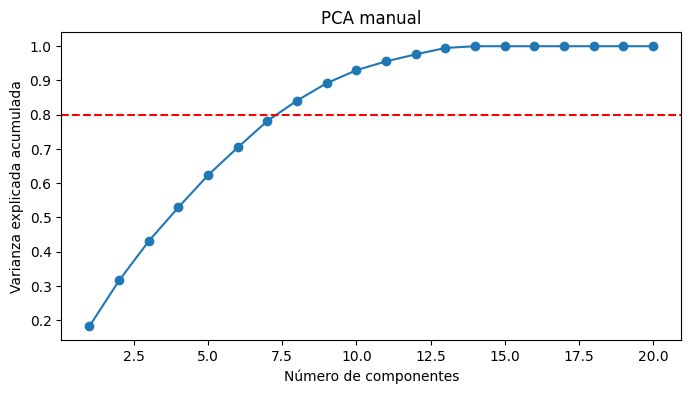

In [24]:
#Aquí lo que estamos haciendo es seleccionar variables para el análisis no supervisado sin usar directamente la variable objetivo.
columnas_unsup = [
    "nota_admision",
    "nota_cualificacion_previa",
    "edad_al_matricularse",
    "asignaturas_1sem_matriculadas",
    "asignaturas_1sem_evaluadas",
    "asignaturas_1sem_aprobadas",
    "nota_media_1sem",
    "asignaturas_1sem_sin_evaluacion",
    "becado",
    "deudor",
    "matricula_al_dia",
    "genero",
    "desplazado",
    "internacional"]

#Preparamos la matriz no supervisada y aplicamos PCA manual.
datos_unsup_raw = df[columnas_unsup].copy()
X_unsup = preparar_matriz_unica_unsup(datos_unsup_raw)

scores_pca, cargas_pca, autovalores_pca, varianza_pca = pca_manual(X_unsup.to_numpy(dtype=float))

#Por último calculamos cuántas componentes necesitamos para explicar al menos el 80% de la varianza.
varianza_acumulada = np.cumsum(varianza_pca)
n_componentes_80 = int(np.searchsorted(varianza_acumulada, 0.80) + 1)

print("Dimensión original:", X_unsup.shape[1])
print("Componentes para explicar al menos el 80%:", n_componentes_80)

#Y representamos la varianza explicada acumulada para justificar la reducción de dimensión.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.axhline(0.80, color="red", linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA manual")
plt.show()


Aquí la interpretación importante no es solo cuántas componentes salen, sino por qué elegimos ese número. En este caso, se ha usado  el umbral del 80% de varianza explicada acumulada por el hecho de que queremos reducir dimensión sin perder demasiada información global del dataset.

In [25]:
#Nos quedamos con las componentes principales necesarias para hacer clustering.
n_componentes_cluster = max(2, n_componentes_80)
X_cluster = scores_pca[:, :n_componentes_cluster]
dist_cluster = matriz_distancias(X_cluster)

resultados_kmeans = []

#Probamos varios números de clusters y evaluar cada solución con inercia y silueta.
for k in range(2, 7):
    labels_k, centroides_k, inercia_k = kmeans_manual(X_cluster,n_clusters=k,random_state=42,n_init=10,max_iter=100,tol=1e-4,)

    silhouette_k = silhouette_manual(dist_cluster, labels_k)
    resultados_kmeans.append({"k": k,"inercia": inercia_k,"silueta": silhouette_k,})

#Por último, ordenamos los resultados para elegir primero por mejor silueta y después por menor inercia.
resultados_kmeans = pd.DataFrame(resultados_kmeans).sort_values(["silueta", "inercia"],ascending=[False, True],)

print(resultados_kmeans.to_string(index=False))
print()

mejor_k_unsup = int(resultados_kmeans.iloc[0]["k"])
print("Número de clusters elegido:", mejor_k_unsup)


 k      inercia  silueta
 5 40061.649245 0.265435
 6 36086.545501 0.265184
 2 63260.482654 0.262408
 4 48192.947400 0.238713
 3 53972.543257 0.223877

Número de clusters elegido: 5


Para elegir el número de clusters tenemos el método del codo, que consiste en comprobar si aumentar k sigue reduciendo mucho la inercia o ya no compensa, y por otro lado, el método de la silueta, que mide si los grupos quedan compactos por dentro y bien separados entre sí

En este caso usamos la silueta como criterio principal de elección y la inercia como apoyo, porque así no solo exigimos grupos pequeños, sino también grupos bien definidos.